#COMPS TABLE

#Data sourced from Yahoo Finance via yfinance API; values are indicative and may differ from Bloomberg/FactSet by 5–15% due to API lag and IFRS vs adjusted EBITDA differences

In [24]:
#Cell 1: Install and import 

import subprocess
subprocess.run(['pip', 'install', 'yfinance', '--quiet'])

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All tools loaded. Ready to build")

All tools loaded. Ready to build


In [25]:
# CELL 2: Define all 40 DAX companies with their tickers and sectors

DAX40 = {
    # Technology
    'SAP.DE':   ('SAP SE', 'Technology'),
    'IFX.DE':   ('Infineon Technologies', 'Technology'),

    # Healthcare
    'SHL.DE':   ('Siemens Healthineers', 'Healthcare'),
    'SRT.DE':   ('Sartorius AG', 'Healthcare'),
    'MRK.DE':   ('Merck KGaA', 'Healthcare'),
    'BAYN.DE':  ('Bayer AG', 'Healthcare'),
    'FRE.DE':   ('Fresenius SE', 'Healthcare'),
    'QIA.DE':   ('Qiagen NV', 'Healthcare'),

    # Industrials
    'SIE.DE':   ('Siemens AG', 'Industrials'),
    'ENR.DE':   ('Siemens Energy', 'Industrials'),
    'RHM.DE':   ('Rheinmetall AG', 'Industrials'),
    'MTX.DE':   ('MTU Aero Engines', 'Industrials'),
    'KGX.DE':   ('KION Group', 'Industrials'),
    'HEI.DE':  ('Heidelberg Materials', 'Industrials'),
    'BNR.DE':   ('Brenntag SE', 'Industrials'),
    'AIR.DE':   ('Airbus SE', 'Industrials'),

    # Automotive
    'BMW.DE':   ('BMW AG', 'Automotive'),
    'MBG.DE':   ('Mercedes-Benz Group', 'Automotive'),
    'CON.DE':   ('Continental AG', 'Automotive'),
    'DTG.DE':   ('Daimler Truck', 'Automotive'),
    'PAH3.DE':  ('Porsche SE', 'Automotive'),
    'P911.DE':  ('Porsche AG', 'Automotive'),
    'VOW3.DE':  ('Volkswagen AG', 'Automotive'),
    
    # Financials
    'ALV.DE':   ('Allianz SE', 'Financials'),
    'MUV2.DE':  ('Munich Re', 'Financials'),
    'DBK.DE':   ('Deutsche Bank', 'Financials'),
    'CBK.DE':   ('Commerzbank', 'Financials'),
    'DB1.DE':   ('Deutsche Boerse', 'Financials'),
    'HNR1.DE':  ('Hannover Re', 'Financials'),
    'VNA.DE':   ('Vonovia SE', 'Financials'),

    # Chemicals & Materials
    'BAS.DE':   ('BASF SE', 'Chemicals'),
    'SY1.DE':   ('Symrise AG', 'Chemicals'),

    # Consumer & Retail
    'BEI.DE':   ('Beiersdorf AG', 'Consumer'),
    'HEN3.DE':  ('Henkel AG', 'Consumer'),
    'ZAL.DE':   ('Zalando SE', 'Consumer'),
    'ADS.DE':   ('Adidas AG', 'Consumer'),

    # Energy & Utilities
    'RWE.DE':   ('RWE AG', 'Energy'),
    'EOAN.DE':  ('E.ON SE', 'Energy'),

    # Telecom
    'DTE.DE':   ('Deutsche Telekom', 'Telecom'),
    'DHL.DE':   ('Deutsche Post DHL', 'Logistics'),
}

print(f"Universe defined: {len(DAX40)} companies across {len(set(v[1] for v in DAX40.values()))} sectors")

Universe defined: 40 companies across 10 sectors


In [26]:
# CELL 3: Pull real financial data from Yahoo Finance for every company

records = []

for ticker, (name, sector) in DAX40.items():
    try:
        info = yf.Ticker(ticker).info

        ev     = info.get('enterpriseValue')
        ebitda = info.get('ebitda')
        mktcap = info.get('marketCap')
        pe     = info.get('trailingPE')
        rev    = info.get('totalRevenue')

        ev_ebitda_direct = info.get('enterpriseToEbitda')
        ev_ebitda = round(ev_ebitda_direct, 1) if ev_ebitda_direct else (
            round(ev / ebitda, 1) if ev and ebitda and ebitda > 0 else None
        )
        ev_rev    = round(ev / rev, 1)    if ev and rev and rev > 0 else None

        records.append({
            'Ticker':          ticker,
            'Company':         name,
            'Sector':          sector,
            'EV (EUR bn)':     round(ev / 1e9, 1) if ev else None,
            'EBITDA (EUR bn)': round(ebitda / 1e9, 1) if ebitda else None,
            'Revenue (EUR bn)':round(rev / 1e9, 1) if rev else None,
            'Mkt Cap (EUR bn)':round(mktcap / 1e9, 1) if mktcap else None,
            'EV/EBITDA (x)':   ev_ebitda,
            'EV/Revenue (x)':  ev_rev,
            'P/E (x)':         round(pe, 1) if pe else None,
        })

        status = f"{ev_ebitda}x" if ev_ebitda else "no data"
        print(f"  ✓ {name:35s} EV/EBITDA: {status}")

    except Exception as e:
        print(f"  ✗ {name}: skipped")

df = pd.DataFrame(records)

# Flag companies where EV/EBITDA is structurally unreliable
flags = {
    'PAH3.DE': 'N/M – holding co',
    'ALV.DE':  'N/M – insurer',
    'MUV2.DE': 'N/M – insurer',
    'HNR1.DE': 'N/M – insurer',
    'DBK.DE':  'N/M – bank',
    'CBK.DE':  'N/M – bank',
    'VNA.DE':  'N/M – REIT',
    'BMW.DE':  'EV adj. reqd',
    'MBG.DE':  'EV adj. reqd',
    'VOW3.DE': 'EV adj. reqd',
    'DTG.DE':  'EV adj. reqd',
    'CON.DE':  'EV adj. reqd',
}
df['Data Flag'] = df['Ticker'].map(flags).fillna('OK')

print(f"\nDone. {len(df)} companies loaded.")
print(f"Clean comps: {len(df[df['Data Flag'] == 'OK'])}  |  Flagged: {len(df[df['Data Flag'] != 'OK'])}")

  ✓ SAP SE                              EV/EBITDA: 15.3x
  ✓ Infineon Technologies               EV/EBITDA: 13.8x
  ✓ Siemens Healthineers                EV/EBITDA: 13.1x
  ✓ Sartorius AG                        EV/EBITDA: 18.6x
  ✓ Merck KGaA                          EV/EBITDA: 9.9x
  ✓ Bayer AG                            EV/EBITDA: 7.8x
  ✓ Fresenius SE                        EV/EBITDA: 11.7x
  ✓ Qiagen NV                           EV/EBITDA: 11.0x
  ✓ Siemens AG                          EV/EBITDA: 17.9x
  ✓ Siemens Energy                      EV/EBITDA: 37.3x
  ✓ Rheinmetall AG                      EV/EBITDA: 36.2x
  ✓ MTU Aero Engines                    EV/EBITDA: 11.8x
  ✓ KION Group                          EV/EBITDA: 8.6x
  ✓ Heidelberg Materials                EV/EBITDA: 9.3x
  ✓ Brenntag SE                         EV/EBITDA: 10.8x
  ✓ Airbus SE                           EV/EBITDA: 15.9x
  ✓ BMW AG                              EV/EBITDA: 9.2x
  ✓ Mercedes-Benz Group             

In [28]:
# CELL 4: Display full DAX40 comps table

from IPython.display import display

display_cols = ['Company', 'Sector', 'Mkt Cap (EUR bn)', 'EV (EUR bn)',
                'EV/EBITDA (x)', 'EV/Revenue (x)', 'P/E (x)', 'Data Flag']

df_display = df[display_cols].sort_values(['Sector', 'EV/EBITDA (x)']).reset_index(drop=True)
df_display.index = range(1, len(df_display) + 1)

def flag_color(row):
    if 'N/M' in str(row['Data Flag']):
        return ['background-color: #ffe6e6'] * len(row)
    elif 'adj' in str(row['Data Flag']):
        return ['background-color: #fff3cd'] * len(row)
    return [''] * len(row)

def fmt(x, suffix='x'):
    return f'{x:.1f}{suffix}' if pd.notna(x) else 'N/M'

styled = (df_display.style
    .apply(flag_color, axis=1)
    .format({
        'Mkt Cap (EUR bn)': lambda x: fmt(x, ''),
        'EV (EUR bn)':      lambda x: fmt(x, ''),
        'EV/EBITDA (x)':   lambda x: fmt(x),
        'EV/Revenue (x)':  lambda x: fmt(x),
        'P/E (x)':         lambda x: fmt(x),
    })
    .set_caption('DAX 40 Trading Comparables — April 2026')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]}])
)

display(styled)

,Company,Sector,Mkt Cap (EUR bn),EV (EUR bn),EV/EBITDA (x),EV/Revenue (x),P/E (x),Data Flag
1,Porsche SE,Automotive,9.8,14.9,-291.9x,N/M,3.7x,N/M – holding co
2,Continental AG,Automotive,12.5,18.1,7.2x,0.9x,N/M,EV adj. reqd
3,BMW AG,Automotive,48.1,145.2,9.2x,1.1x,6.7x,EV adj. reqd
4,Volkswagen AG,Automotive,43.8,259.2,10.7x,0.8x,6.6x,EV adj. reqd
5,Mercedes-Benz Group,Automotive,46.6,134.7,12.0x,1.0x,9.9x,EV adj. reqd
6,Daimler Truck,Automotive,32.5,51.3,12.5x,1.1x,18.2x,EV adj. reqd
7,Porsche AG,Automotive,36.0,40.2,15.2x,1.1x,84.1x,OK
8,BASF SE,Chemicals,45.0,65.3,10.8x,1.1x,31.8x,OK
9,Symrise AG,Chemicals,10.4,12.0,16.3x,2.4x,41.7x,OK
10,Henkel AG,Consumer,26.4,27.0,8.3x,1.3x,13.2x,OK


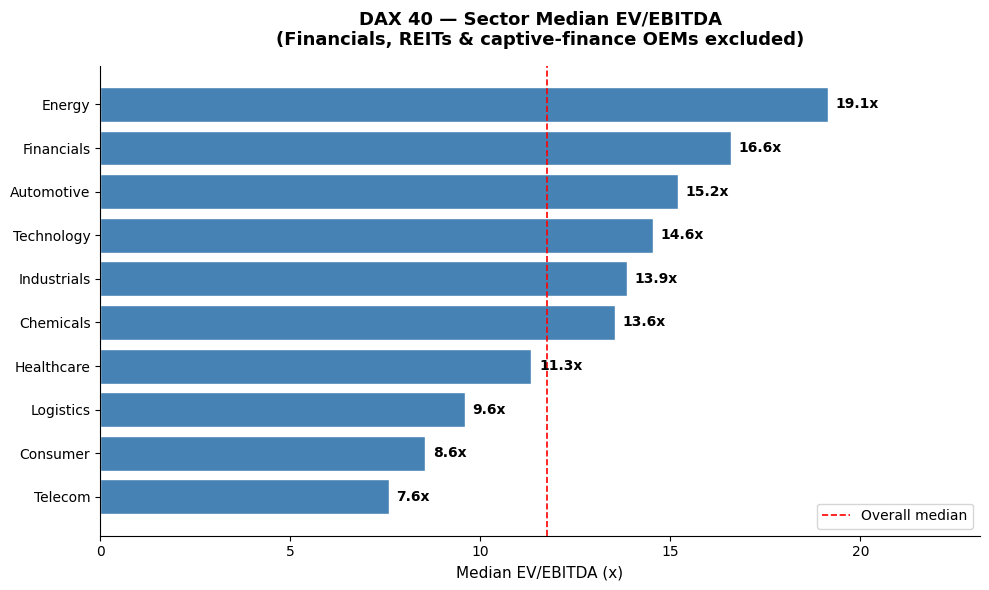

Chart saved.


In [30]:
# CELL 5: Sector median EV/EBITDA bar chart

df_clean = df[df['Data Flag'] == 'OK'].copy()

sector_medians = (df_clean.groupby('Sector')['EV/EBITDA (x)']
                          .median()
                          .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(sector_medians.index, sector_medians.values, color='steelblue', edgecolor='white')

for bar, val in zip(bars, sector_medians.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}x', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Median EV/EBITDA (x)', fontsize=11)
ax.set_title('DAX 40 — Sector Median EV/EBITDA\n(Financials, REITs & captive-finance OEMs excluded)',
             fontsize=13, fontweight='bold', pad=15)
ax.axvline(df_clean['EV/EBITDA (x)'].median(), color='red', linestyle='--', linewidth=1.2, label='Overall median')
ax.legend()
ax.set_xlim(0, sector_medians.max() + 4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dax40_sector_medians.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

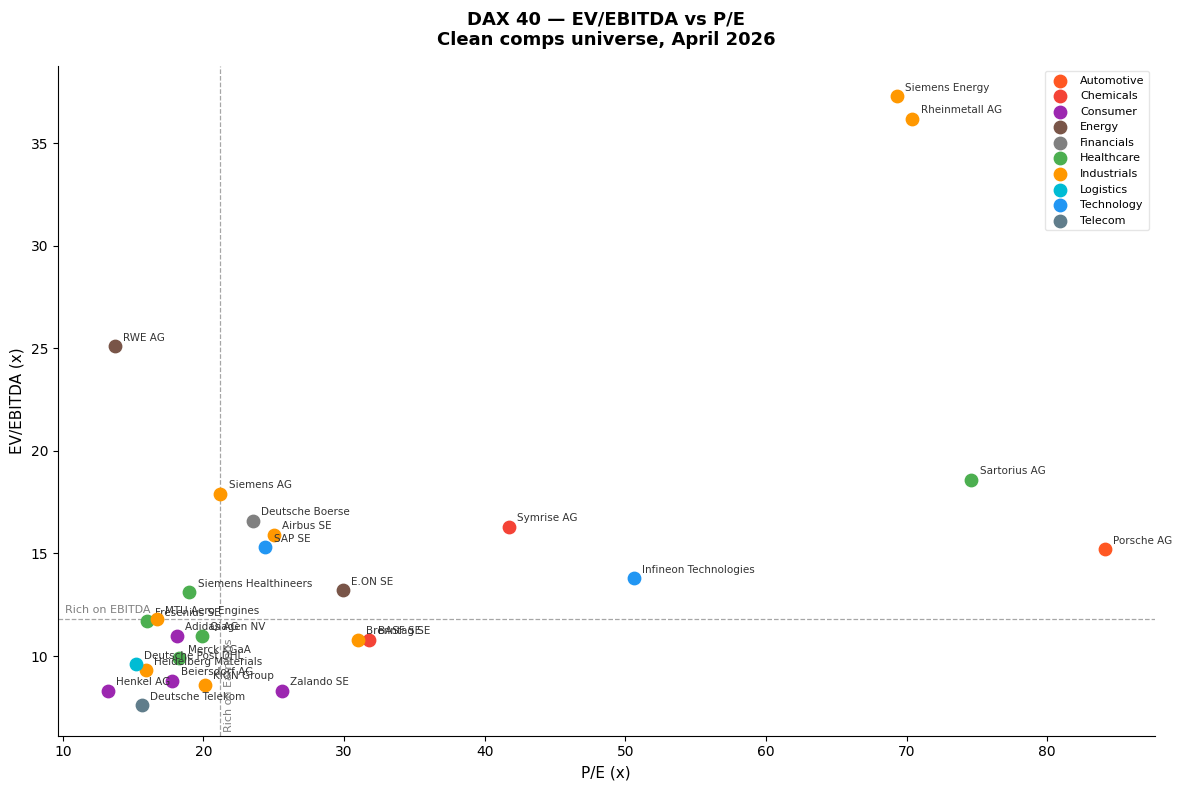

Chart saved.


In [32]:
# CELL 6: Scatter plot — EV/EBITDA vs P/E (cheap vs expensive)

df_scatter = df_clean.dropna(subset=['EV/EBITDA (x)', 'P/E (x)']).copy()

sector_colors = {
    'Technology':  '#2196F3',
    'Healthcare':  '#4CAF50',
    'Industrials': '#FF9800',
    'Consumer':    '#9C27B0',
    'Chemicals':   '#F44336',
    'Energy':      '#795548',
    'Telecom':     '#607D8B',
    'Logistics':   '#00BCD4',
    'Automotive':  '#FF5722',
}

fig, ax = plt.subplots(figsize=(12, 8))

for sector, group in df_scatter.groupby('Sector'):
    color = sector_colors.get(sector, 'grey')
    ax.scatter(group['P/E (x)'], group['EV/EBITDA (x)'],
               color=color, s=80, label=sector, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['Company'],
                    (row['P/E (x)'], row['EV/EBITDA (x)']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7.5, color='#333333')

# Median crosshair lines
med_pe      = df_scatter['P/E (x)'].median()
med_evebitda = df_scatter['EV/EBITDA (x)'].median()
ax.axvline(med_pe,       color='grey', linestyle='--', linewidth=0.9, alpha=0.7)
ax.axhline(med_evebitda, color='grey', linestyle='--', linewidth=0.9, alpha=0.7)

# Quadrant labels
ax.text(ax.get_xlim()[0] + 0.5, med_evebitda + 0.3, 'Rich on EBITDA', fontsize=8, color='grey')
ax.text(med_pe + 0.3,           ax.get_ylim()[0] + 0.3, 'Rich on Earnings', fontsize=8, color='grey', rotation=90)

ax.set_xlabel('P/E (x)', fontsize=11)
ax.set_ylabel('EV/EBITDA (x)', fontsize=11)
ax.set_title('DAX 40 — EV/EBITDA vs P/E\nClean comps universe, April 2026',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=8, framealpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dax40_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [33]:
# CELL 7: Export full comps table to CSV

import os

output_path = 'dax40_trading_comps_april2026.csv'
df.to_csv(output_path, index=False)

print(f"Exported: {output_path}")
print(f"Rows: {len(df)} | Columns: {list(df.columns)}")

Exported: dax40_trading_comps_april2026.csv
Rows: 40 | Columns: ['Ticker', 'Company', 'Sector', 'EV (EUR bn)', 'EBITDA (EUR bn)', 'Revenue (EUR bn)', 'Mkt Cap (EUR bn)', 'EV/EBITDA (x)', 'EV/Revenue (x)', 'P/E (x)', 'Data Flag']


## DAX 40 Trading Comparables — Key Observations
### April 2026 | Data: Yahoo Finance via yfinance API

---

### Universe & Methodology
40-company DAX universe screened across 10 sectors. EV/EBITDA is the primary valuation metric.
Financials (banks, insurers), REITs, and captive-finance OEMs (BMW, Mercedes, VW, Daimler Truck)
excluded from sector medians — EV/EBITDA is structurally distorted for these business models.
Clean comps universe: ~27 companies. Data sourced April 2026; indicative only.

---

### Headline Findings

**1. Defence & Energy Transition are the standout premium sectors**
Rheinmetall (36.2x) and Siemens Energy (37.3x) trade at multiples more typical of high-growth
tech than industrials. Both reflect structural re-rating stories — European rearmament driving
Rheinmetall's order backlog beyond €50bn, and Siemens Energy benefiting from grid infrastructure
spend tied to the energy transition. At these multiples, execution risk is fully priced in.

**2. Bayer is the clearest value outlier — but for a reason**
At 7.8x EV/EBITDA, Bayer screens as the cheapest non-financial in the index. The discount is
not a mystery: Roundup/glyphosate litigation remains unresolved, the pharma pipeline has faced
setbacks, and dividend cuts have eroded institutional confidence. Classic value trap risk —
cheap on multiples, but the liability overhang is open-ended.

**3. SAP commands a structural software premium**
SAP at ~15x trades well above the index median, justified by its cloud transition (S/4HANA
migration) driving recurring revenue growth and margin expansion. As the only large-cap pure
software name in the DAX, it has no direct German-listed peer for comparison.

**4. Within Automotive, Porsche AG stands apart**
With captive-finance OEMs excluded, Porsche AG (P911.DE) at 15.2x is the only automotive name
that reads as a luxury goods company rather than a cyclical manufacturer — consistent with how
Ferrari trades in Italy. The contrast with the broader flagged auto sector illustrates why brand
positioning matters more than sector classification in comps analysis.

**5. Chemicals are under structural pressure**
BASF (10.8x) and Symrise (16.3x) illustrate the split within chemicals — commodity vs specialty.
BASF faces persistent headwinds from high European energy costs and Chinese overcapacity in
downstream products. Symrise, as a specialty flavours and fragrances business, commands a
meaningful premium for its pricing power and non-cyclical end markets.

---

### Data Limitations
- yfinance API values may differ from Bloomberg/FactSet by 5–15% due to IFRS vs adjusted EBITDA
  treatment and API refresh timing
- Captive-finance OEM EVs are inflated by financial services debt; P/E is the preferred metric
  for BMW, Mercedes-Benz, Volkswagen, and Daimler Truck
- Porsche SE (PAH3.DE) excluded — holding company EBITDA is not operationally meaningful